In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [11]:
df = pd.read_csv("superstore_sales.csv")

# Check if the DataFrame was loaded as a single malformed column
malformed_column_name = 'Order_ID,Region,Category,Sales,Profit'
if malformed_column_name in df.columns and len(df.columns) == 1:
    print(f"Warning: DataFrame loaded as a single column '{malformed_column_name}'. Attempting to re-parse.")
    # Split the single malformed column into new columns
    temp_df = df[malformed_column_name].str.split(',', expand=True)
    # Assign new column names based on the malformed column header
    temp_df.columns = malformed_column_name.split(',')

    # Convert 'Sales' and 'Profit' to numeric, handling errors
    temp_df['Sales'] = pd.to_numeric(temp_df['Sales'], errors='coerce')
    temp_df['Profit'] = pd.to_numeric(temp_df['Profit'], errors='coerce')

    df = temp_df
    print("DataFrame 'df' has been successfully re-parsed for correct column access.")

print(df.head())

DataFrame 'df' has been successfully re-parsed for correct column access.
  Order_ID Region         Category  Sales  Profit
0        1  South        Furniture   2500     300
1        2   East       Technology   4500     900
2        3   West  Office Supplies   1200     200
3        4  North        Furniture   3000     450
4        5  South       Technology   5000    1000


In [8]:
print(df.info())

print(df.describe())

print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 1 columns):
 #   Column                                 Non-Null Count  Dtype 
---  ------                                 --------------  ----- 
 0   Order_ID,Region,Category,Sales,Profit  10 non-null     object
dtypes: object(1)
memory usage: 212.0+ bytes
None
       Order_ID,Region,Category,Sales,Profit
count                                     10
unique                                    10
top               1,South,Furniture,2500,300
freq                                       1
Order_ID,Region,Category,Sales,Profit    0
dtype: int64


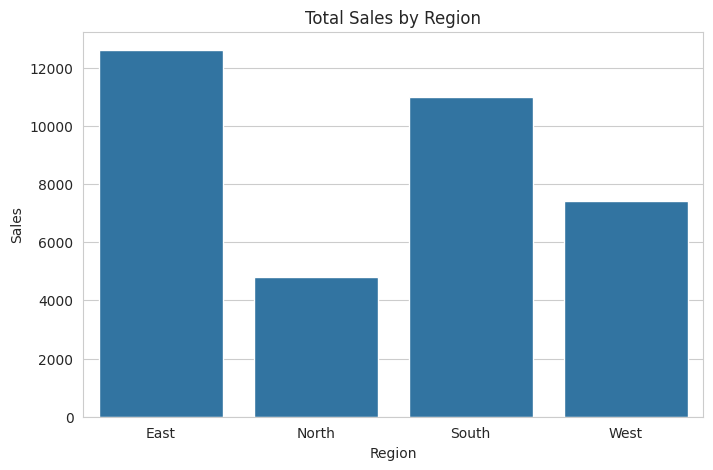

In [12]:
region_sales = df.groupby('Region')['Sales'].sum().reset_index()

plt.figure(figsize=(8,5))

sns.barplot(
    data=region_sales,
    x='Region',
    y='Sales'
)

plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")

plt.show()

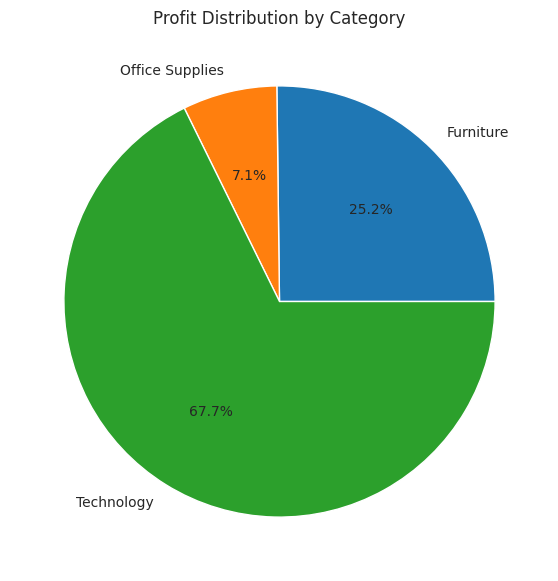

In [13]:
category_profit = df.groupby('Category')['Profit'].sum()

plt.figure(figsize=(7,7))

plt.pie(
    category_profit,
    labels=category_profit.index,
    autopct='%1.1f%%'
)

plt.title("Profit Distribution by Category")

plt.show()

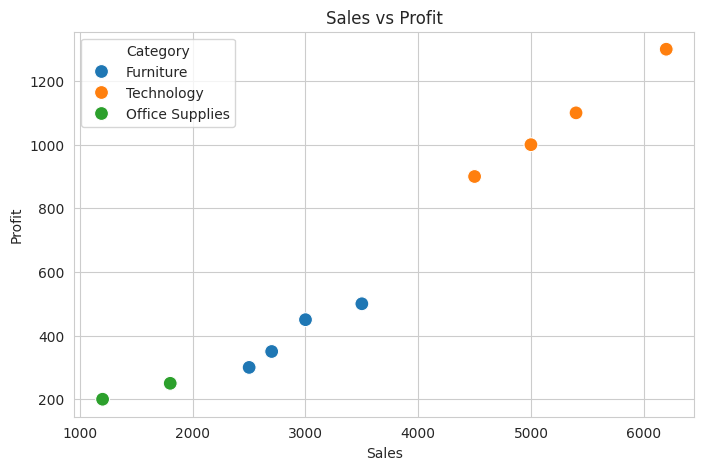

In [14]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Sales',
    y='Profit',
    hue='Category',
    s=100
)

plt.title("Sales vs Profit")

plt.show()

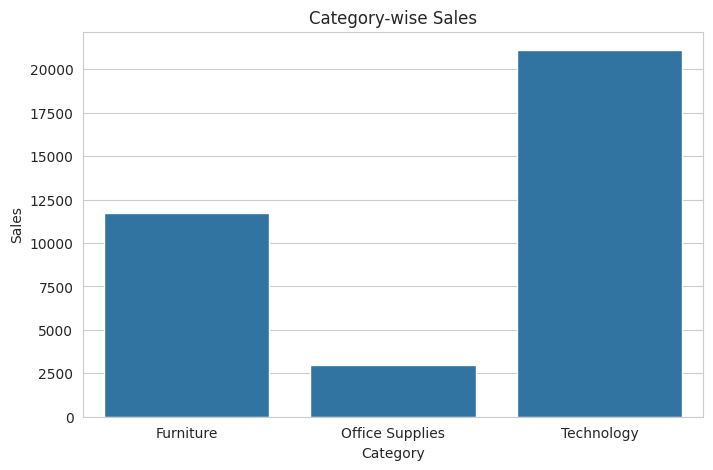

In [15]:
category_sales = df.groupby('Category')['Sales'].sum().reset_index()

plt.figure(figsize=(8,5))

sns.barplot(
    data=category_sales,
    x='Category',
    y='Sales'
)

plt.title("Category-wise Sales")

plt.show()

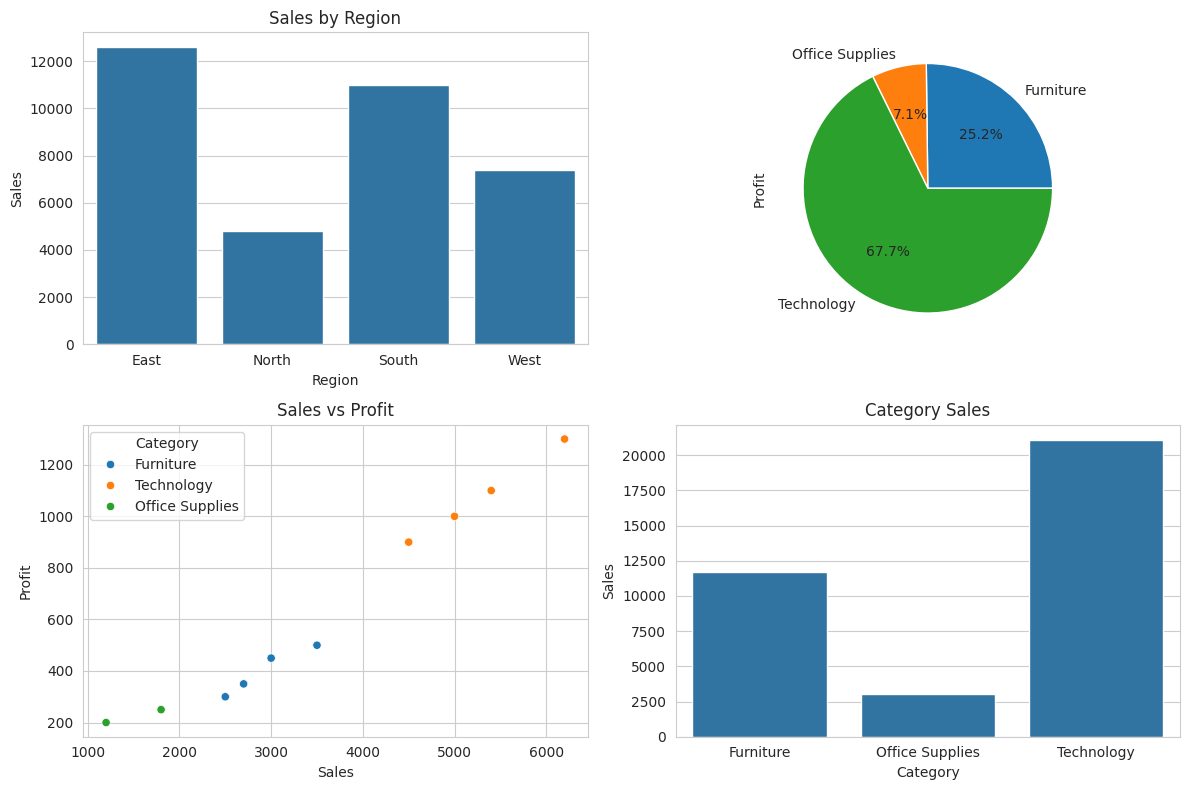

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(12,8))

# Sales by Region
sns.barplot(
    data=region_sales,
    x='Region',
    y='Sales',
    ax=axes[0,0]
)
axes[0,0].set_title("Sales by Region")

# Profit by Category
category_profit.plot(
    kind='pie',
    autopct='%1.1f%%',
    ax=axes[0,1]
)

# Scatter Plot
sns.scatterplot(
    data=df,
    x='Sales',
    y='Profit',
    hue='Category',
    ax=axes[1,0]
)
axes[1,0].set_title("Sales vs Profit")

# Category Sales
sns.barplot(
    data=category_sales,
    x='Category',
    y='Sales',
    ax=axes[1,1]
)
axes[1,1].set_title("Category Sales")

plt.tight_layout()
plt.show()